In [2]:
from __future__ import annotations

import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'exp').exists():
            return candidate
    raise FileNotFoundError('Could not locate the HW5 repository root.')

repo_root = find_repo_root()
exp_dir = repo_root / 'exp'
plots_dir = repo_root / 'plots'
plots_dir.mkdir(exist_ok=True)

CUBE_ENV = 'cube-single-play-singletask-task1-v0'
ANT_ENV = 'antsoccer-arena-navigate-singletask-task1-v0'

ALGO_LABELS = {
    'sacbc': 'SAC+BC',
    'iql': 'IQL',
    'fql': 'FQL',
}

ENV_LABELS = {
    CUBE_ENV: 'Cube-Single',
    ANT_ENV: 'Antsoccer-Arena',
}

print(f'repo_root: {repo_root}')
print(f'exp_dir: {exp_dir}')
print(f'plots_dir: {plots_dir}')

repo_root: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5
exp_dir: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\exp
plots_dir: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots


In [3]:
def read_csv_rows(path: Path) -> list[dict[str, str]]:
    with path.open(newline='') as handle:
        return list(csv.DictReader(handle))

def format_alpha(alpha: float) -> str:
    return str(int(alpha)) if float(alpha).is_integer() else f'{alpha:g}'

def load_runs() -> list[dict]:
    runs = []
    for question_dir in sorted(exp_dir.glob('q*')):
        for run_dir in sorted(question_dir.iterdir()):
            if not run_dir.is_dir():
                continue

            flags_path = run_dir / 'flags.json'
            eval_path = run_dir / 'eval.csv'
            if not flags_path.exists() or not eval_path.exists():
                continue

            flags = json.loads(flags_path.read_text())
            eval_rows = read_csv_rows(eval_path)
            if not eval_rows:
                continue

            curve = [
                {
                    'step': int(float(row['step'])),
                    'success': float(row['eval/success_rate']),
                }
                for row in eval_rows
            ]
            best_point = max(curve, key=lambda point: point['success'])

            runs.append({
                'question': question_dir.name,
                'algorithm': flags['agent'],
                'env': flags['env_name'],
                'alpha': float(flags['agent_kwargs']['alpha']),
                'run_name': run_dir.name,
                'run_dir': run_dir,
                'curve': curve,
                'final_step': curve[-1]['step'],
                'final_success': curve[-1]['success'],
                'best_step': best_point['step'],
                'best_success': best_point['success'],
            })

    return runs

runs = load_runs()
print(f'Loaded {len(runs)} runs.')

def get_runs(question: str, algorithm: str, env: str) -> list[dict]:
    return [
        run for run in runs
        if run['question'] == question and run['algorithm'] == algorithm and run['env'] == env
    ]

def choose_best_run(question: str, env: str, run_list: list[dict]) -> dict:
    if question == 'q3' and env == ANT_ENV:
        return max(run_list, key=lambda run: (run['best_success'], run['final_success'], -run['alpha']))
    return max(run_list, key=lambda run: (run['final_success'], run['best_success'], -run['alpha']))

def alpha_sweep(question: str, algorithm: str, env: str) -> list[dict]:
    return sorted(get_runs(question, algorithm, env), key=lambda run: run['alpha'])

best_runs = {}
for question in sorted({run['question'] for run in runs}):
    for algorithm in sorted({run['algorithm'] for run in runs if run['question'] == question}):
        for env in sorted({run['env'] for run in runs if run['question'] == question and run['algorithm'] == algorithm}):
            candidates = get_runs(question, algorithm, env)
            if candidates:
                best_runs[(question, algorithm, env)] = choose_best_run(question, env, candidates)

Loaded 22 runs.


In [4]:
def format_steps(step: float, _pos=None) -> str:
    step = int(step)
    if step >= 1_000_000:
        return '1M'
    if step >= 1_000:
        return f'{step // 1_000}k'
    return str(step)

def plot_success_curves(run_list: list[dict], title: str, file_name: str) -> Path:
    fig, ax = plt.subplots(figsize=(8, 5), dpi=160)
    colors = plt.cm.tab10.colors

    for index, run in enumerate(run_list):
        steps = [point['step'] for point in run['curve']]
        success = [point['success'] for point in run['curve']]
        label = f"alpha={format_alpha(run['alpha'])}"
        ax.plot(
            steps,
            success,
            marker='o',
            markersize=4,
            linewidth=2.2,
            color=colors[index % len(colors)],
            label=label,
        )

    ax.set_title(title)
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Success Rate')
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(FuncFormatter(format_steps))
    ax.grid(True, alpha=0.3)
    ax.legend(title='Alpha')
    fig.tight_layout()

    out_path = plots_dir / file_name
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'Saved figure to: {out_path}')
    return out_path

def print_group_summary(question: str, algorithm: str, env: str) -> None:
    group = alpha_sweep(question, algorithm, env)
    selected = best_runs[(question, algorithm, env)]
    criterion = 'best peak success' if question == 'q3' and env == ANT_ENV else 'best final success'

    print(f'=== {question} | {ALGO_LABELS[algorithm]} | {ENV_LABELS[env]} ===')
    for run in group:
        print(
            f"alpha={format_alpha(run['alpha']):<5} final={run['final_success']:.2%} "
            f"best={run['best_success']:.2%}@{format_steps(run['best_step'])} "
            f"run={run['run_name']}"
        )
    print(
        f"Selected by {criterion}: alpha={format_alpha(selected['alpha'])}, "
        f"final={selected['final_success']:.2%}, best={selected['best_success']:.2%}@{format_steps(selected['best_step'])}"
    )
    print()

In [5]:
print_group_summary('q1', 'sacbc', CUBE_ENV)
print_group_summary('q1', 'sacbc', ANT_ENV)
print_group_summary('q2', 'iql', CUBE_ENV)
print_group_summary('q2', 'iql', ANT_ENV)
print_group_summary('q3', 'fql', CUBE_ENV)
print_group_summary('q3', 'fql', ANT_ENV)

=== q1 | SAC+BC | Cube-Single ===
alpha=30    final=84.00% best=92.00%@900k run=sd0_20260419_063724_sacbc_cube-single-play-singletask-task1-v0_a30.0
alpha=100   final=96.00% best=100.00%@500k run=sd0_20260419_063724_sacbc_cube-single-play-singletask-task1-v0_a100.0
alpha=300   final=96.00% best=100.00%@400k run=sd0_20260419_063724_sacbc_cube-single-play-singletask-task1-v0_a300.0
alpha=1000  final=88.00% best=92.00%@800k run=sd0_20260419_063724_sacbc_cube-single-play-singletask-task1-v0_a1000.0
Selected by best final success: alpha=100, final=96.00%, best=100.00%@500k

=== q1 | SAC+BC | Antsoccer-Arena ===
alpha=1     final=0.00% best=4.00%@600k run=sd0_20260419_063929_sacbc_antsoccer-arena-navigate-singletask-task1-v0_a1.0
alpha=3     final=12.00% best=36.00%@800k run=sd0_20260419_063929_sacbc_antsoccer-arena-navigate-singletask-task1-v0_a3.0
alpha=10    final=8.00% best=24.00%@400k run=sd0_20260419_063929_sacbc_antsoccer-arena-navigate-singletask-task1-v0_a10.0
alpha=30    final=0.00

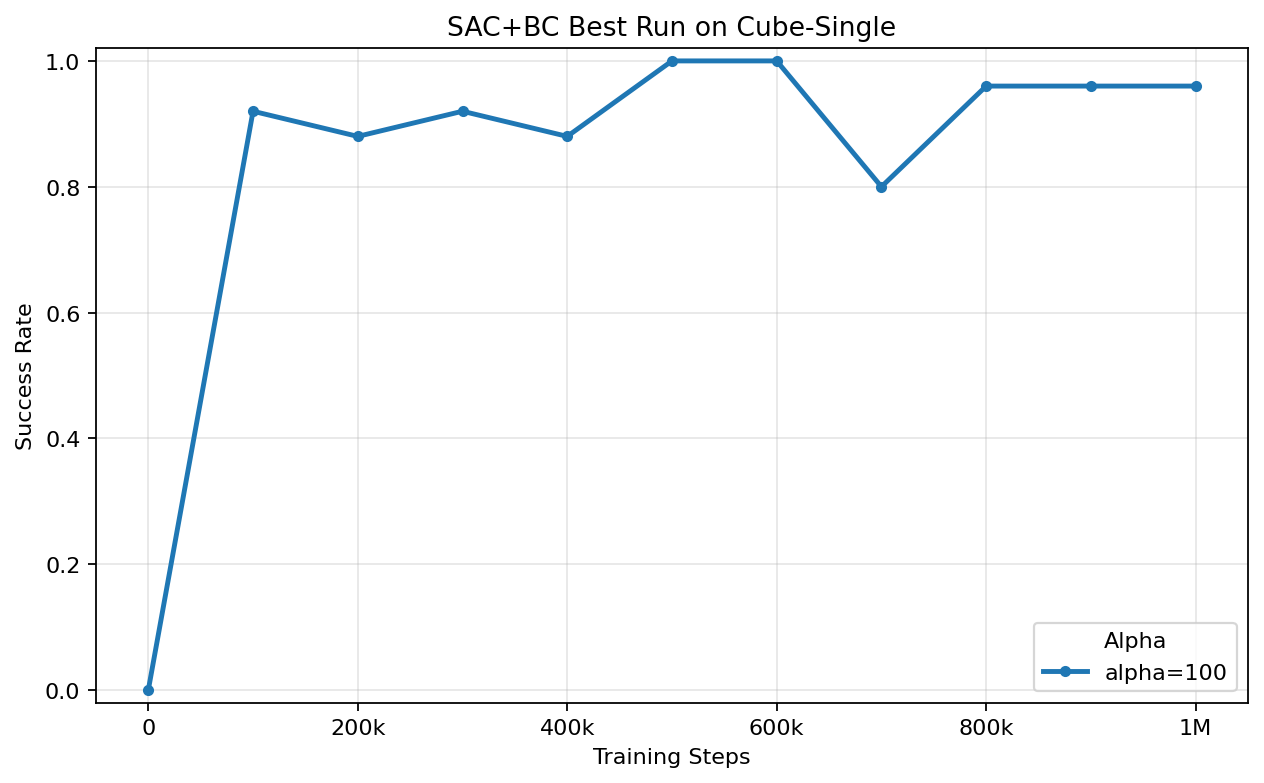

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q1_sacbc_cube_best.png


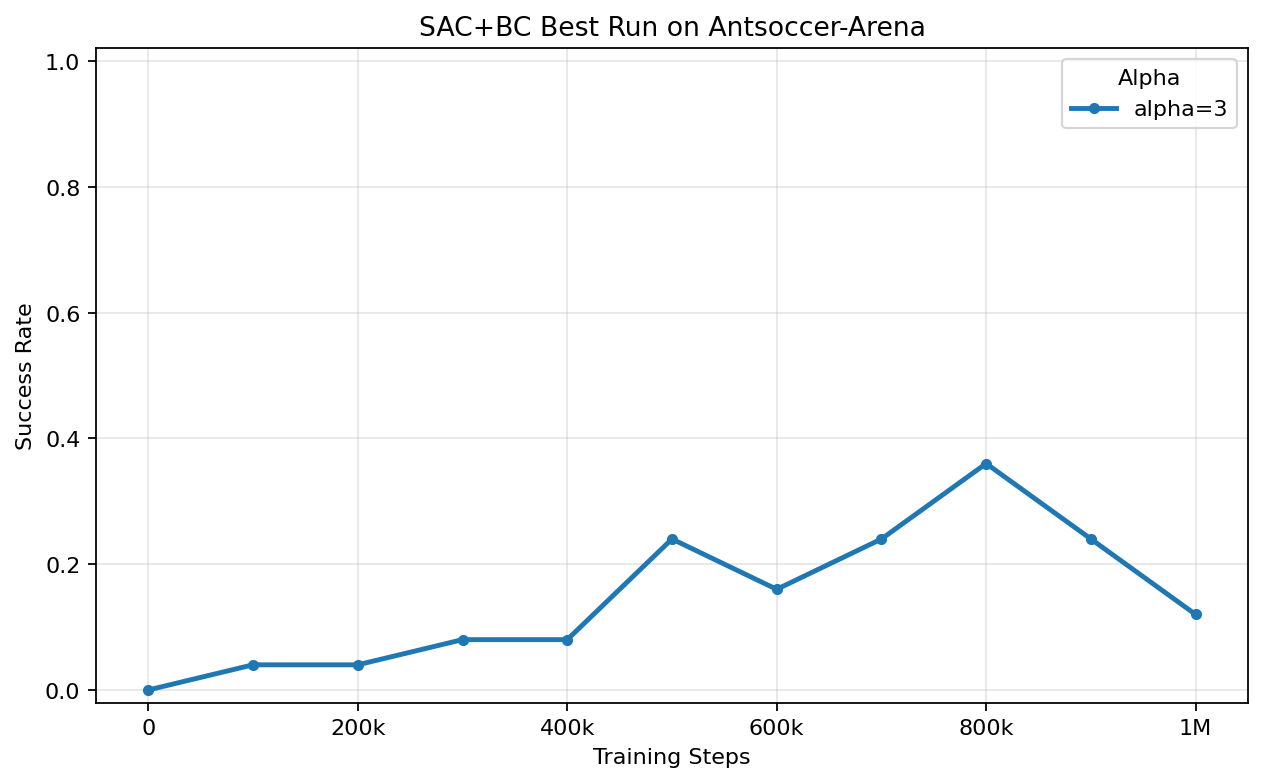

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q1_sacbc_antsoccer_best.png


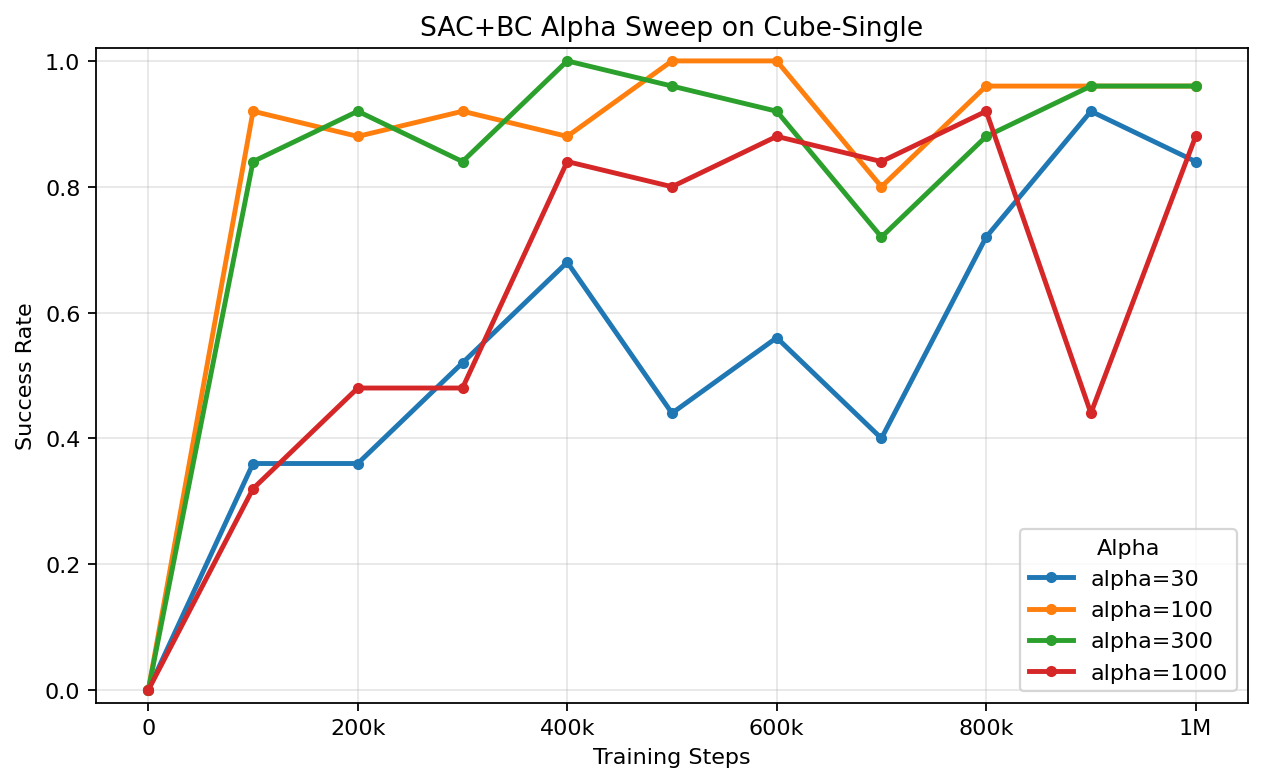

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q1_sacbc_cube_alpha_sweep.png


WindowsPath('C:/Users/prana/Documents/Projects/berkeley/cs285/hw/hw5/plots/q1_sacbc_cube_alpha_sweep.png')

In [6]:
plot_success_curves(
    [best_runs[('q1', 'sacbc', CUBE_ENV)]],
    'SAC+BC Best Run on Cube-Single',
    'q1_sacbc_cube_best.png',
)

plot_success_curves(
    [best_runs[('q1', 'sacbc', ANT_ENV)]],
    'SAC+BC Best Run on Antsoccer-Arena',
    'q1_sacbc_antsoccer_best.png',
)

plot_success_curves(
    alpha_sweep('q1', 'sacbc', CUBE_ENV),
    'SAC+BC Alpha Sweep on Cube-Single',
    'q1_sacbc_cube_alpha_sweep.png',
)

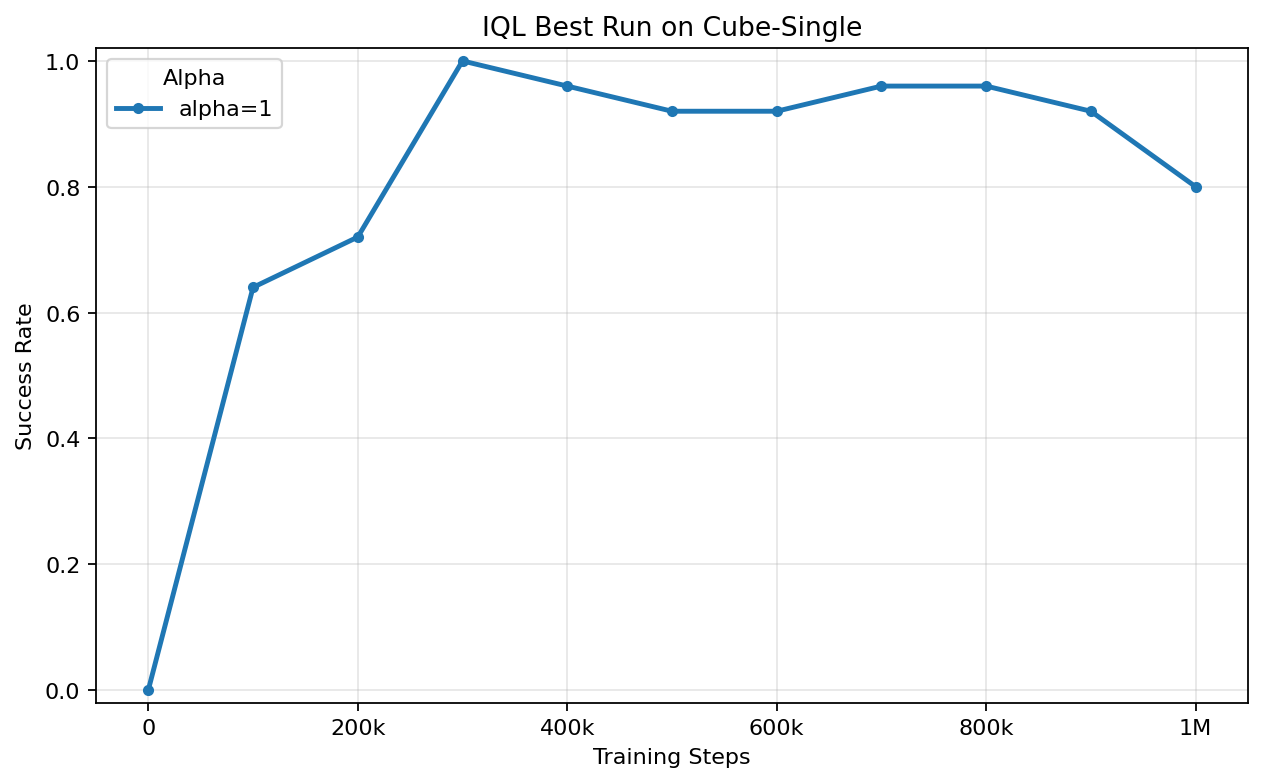

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q2_iql_cube_best.png


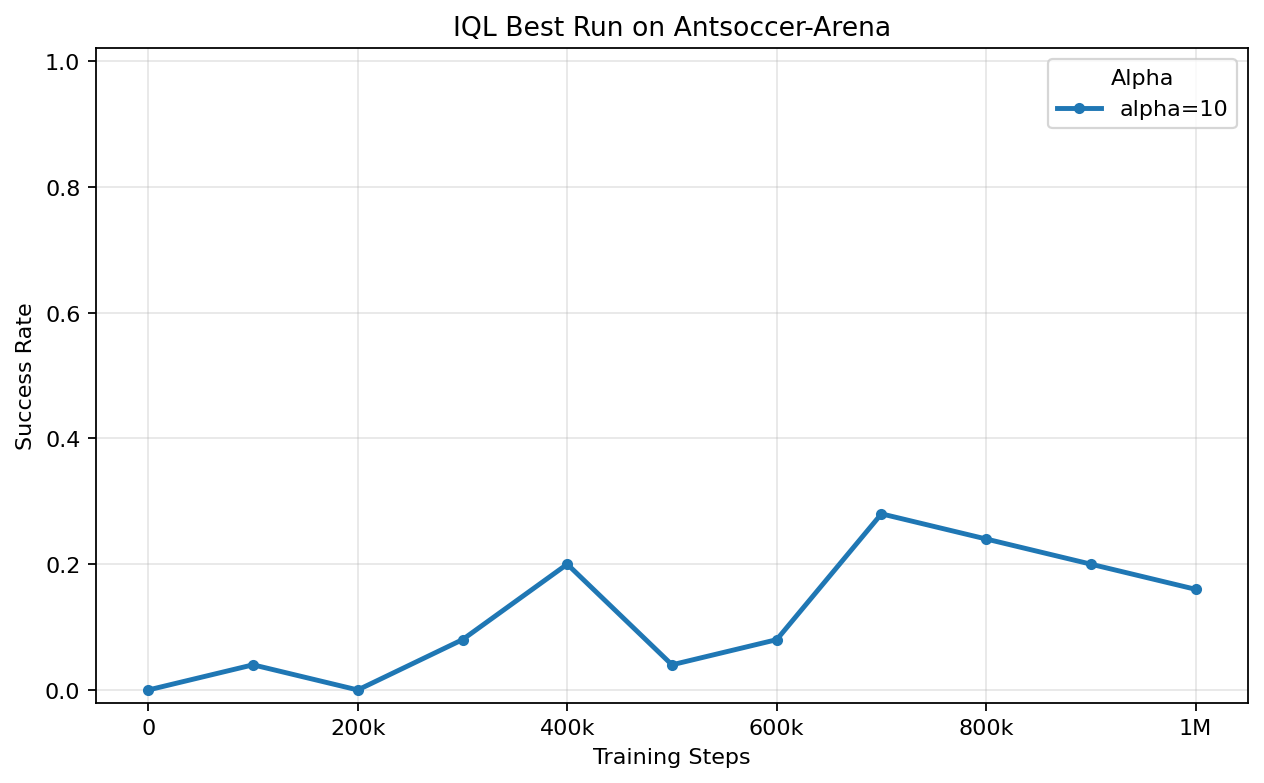

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q2_iql_antsoccer_best.png


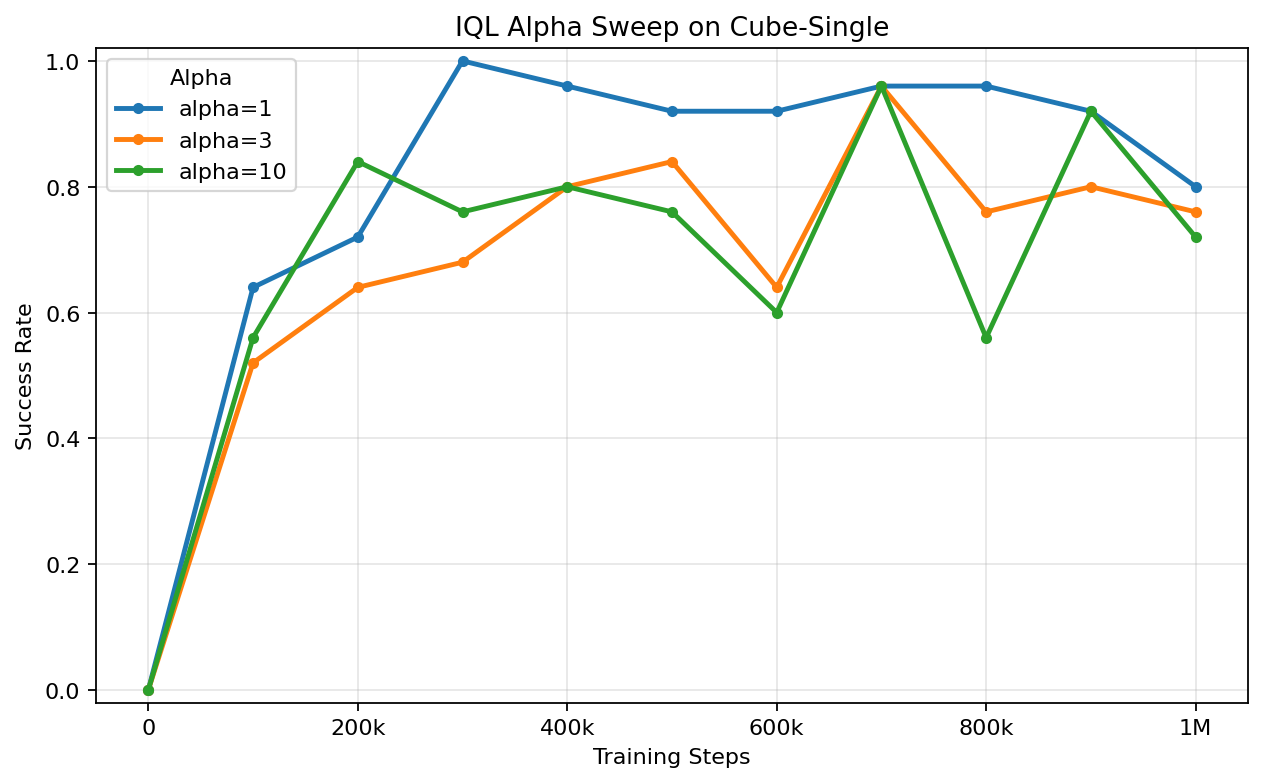

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q2_iql_cube_alpha_sweep.png


WindowsPath('C:/Users/prana/Documents/Projects/berkeley/cs285/hw/hw5/plots/q2_iql_cube_alpha_sweep.png')

In [7]:
plot_success_curves(
    [best_runs[('q2', 'iql', CUBE_ENV)]],
    'IQL Best Run on Cube-Single',
    'q2_iql_cube_best.png',
)

plot_success_curves(
    [best_runs[('q2', 'iql', ANT_ENV)]],
    'IQL Best Run on Antsoccer-Arena',
    'q2_iql_antsoccer_best.png',
)

plot_success_curves(
    alpha_sweep('q2', 'iql', CUBE_ENV),
    'IQL Alpha Sweep on Cube-Single',
    'q2_iql_cube_alpha_sweep.png',
)

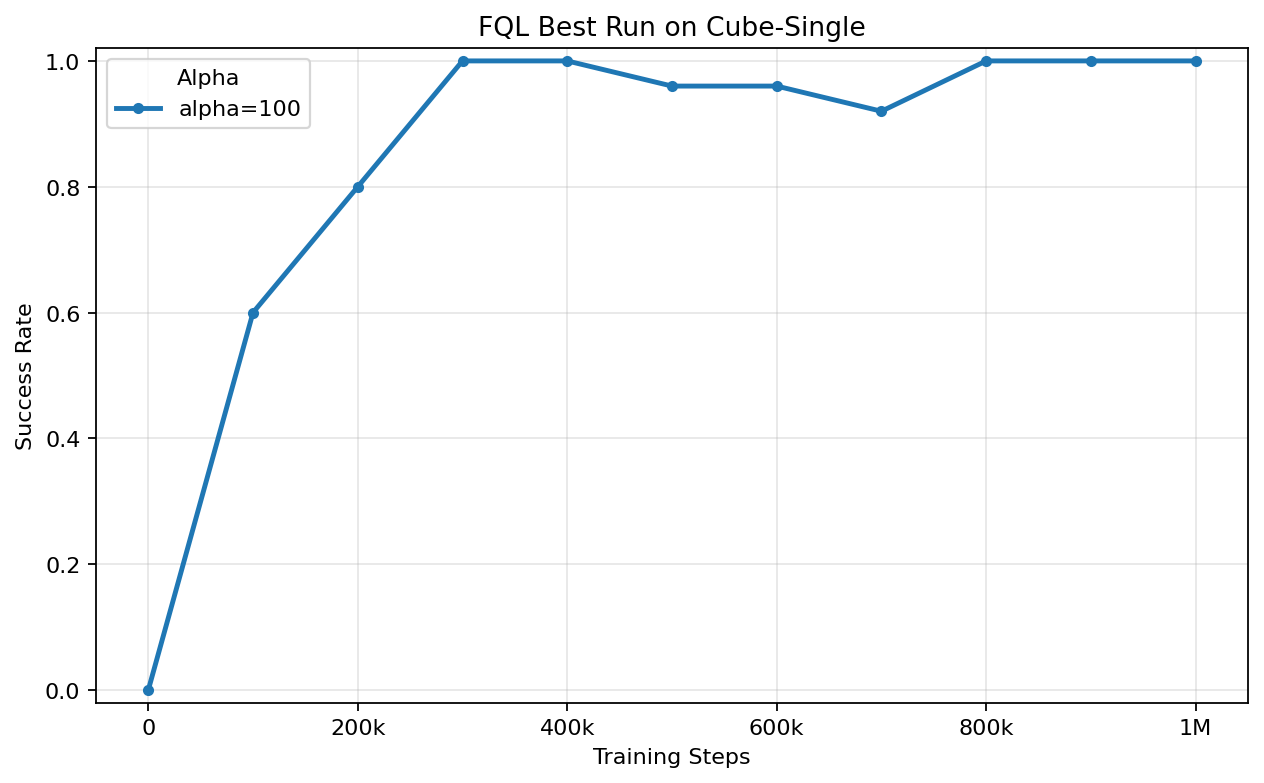

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q3_fql_cube_best.png


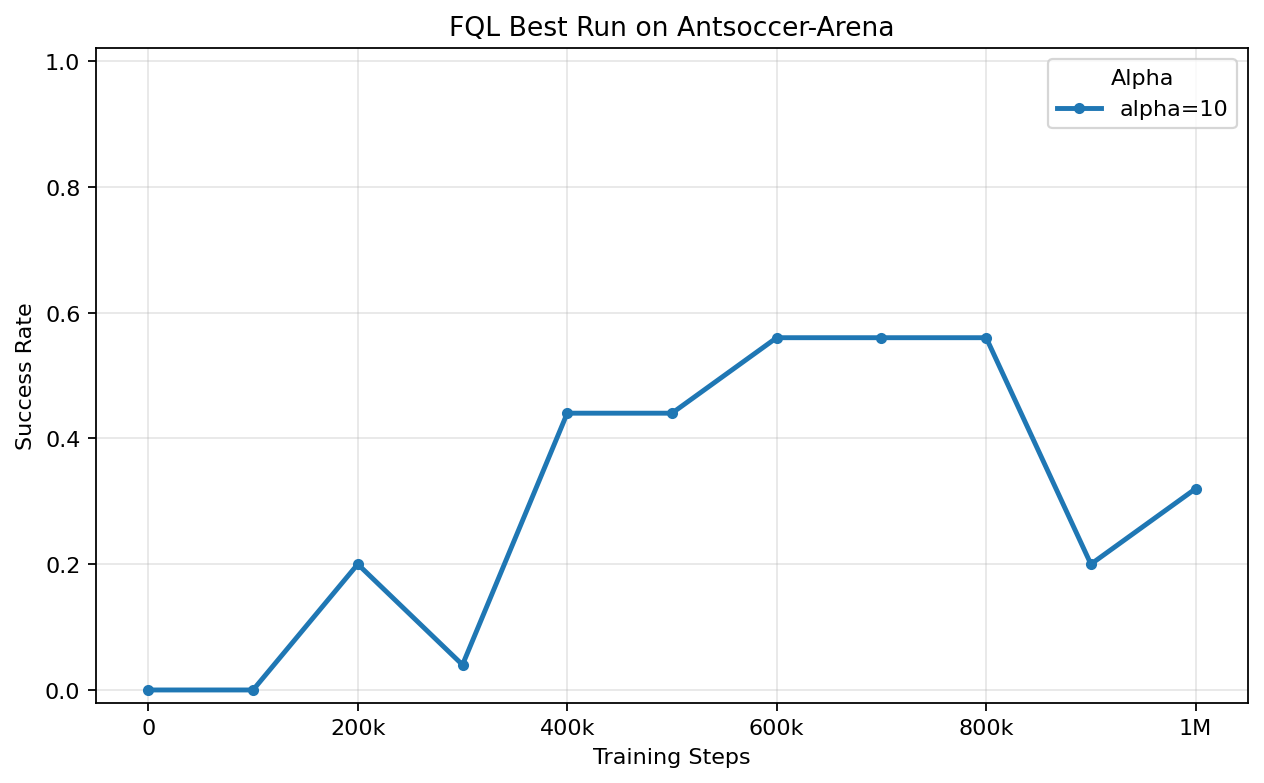

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw5\plots\q3_fql_antsoccer_best.png


WindowsPath('C:/Users/prana/Documents/Projects/berkeley/cs285/hw/hw5/plots/q3_fql_antsoccer_best.png')

In [8]:
plot_success_curves(
    [best_runs[('q3', 'fql', CUBE_ENV)]],
    'FQL Best Run on Cube-Single',
    'q3_fql_cube_best.png',
)

plot_success_curves(
    [best_runs[('q3', 'fql', ANT_ENV)]],
    'FQL Best Run on Antsoccer-Arena',
    'q3_fql_antsoccer_best.png',
)